In [69]:
from analysis_helpers.constants import FIG_DIR

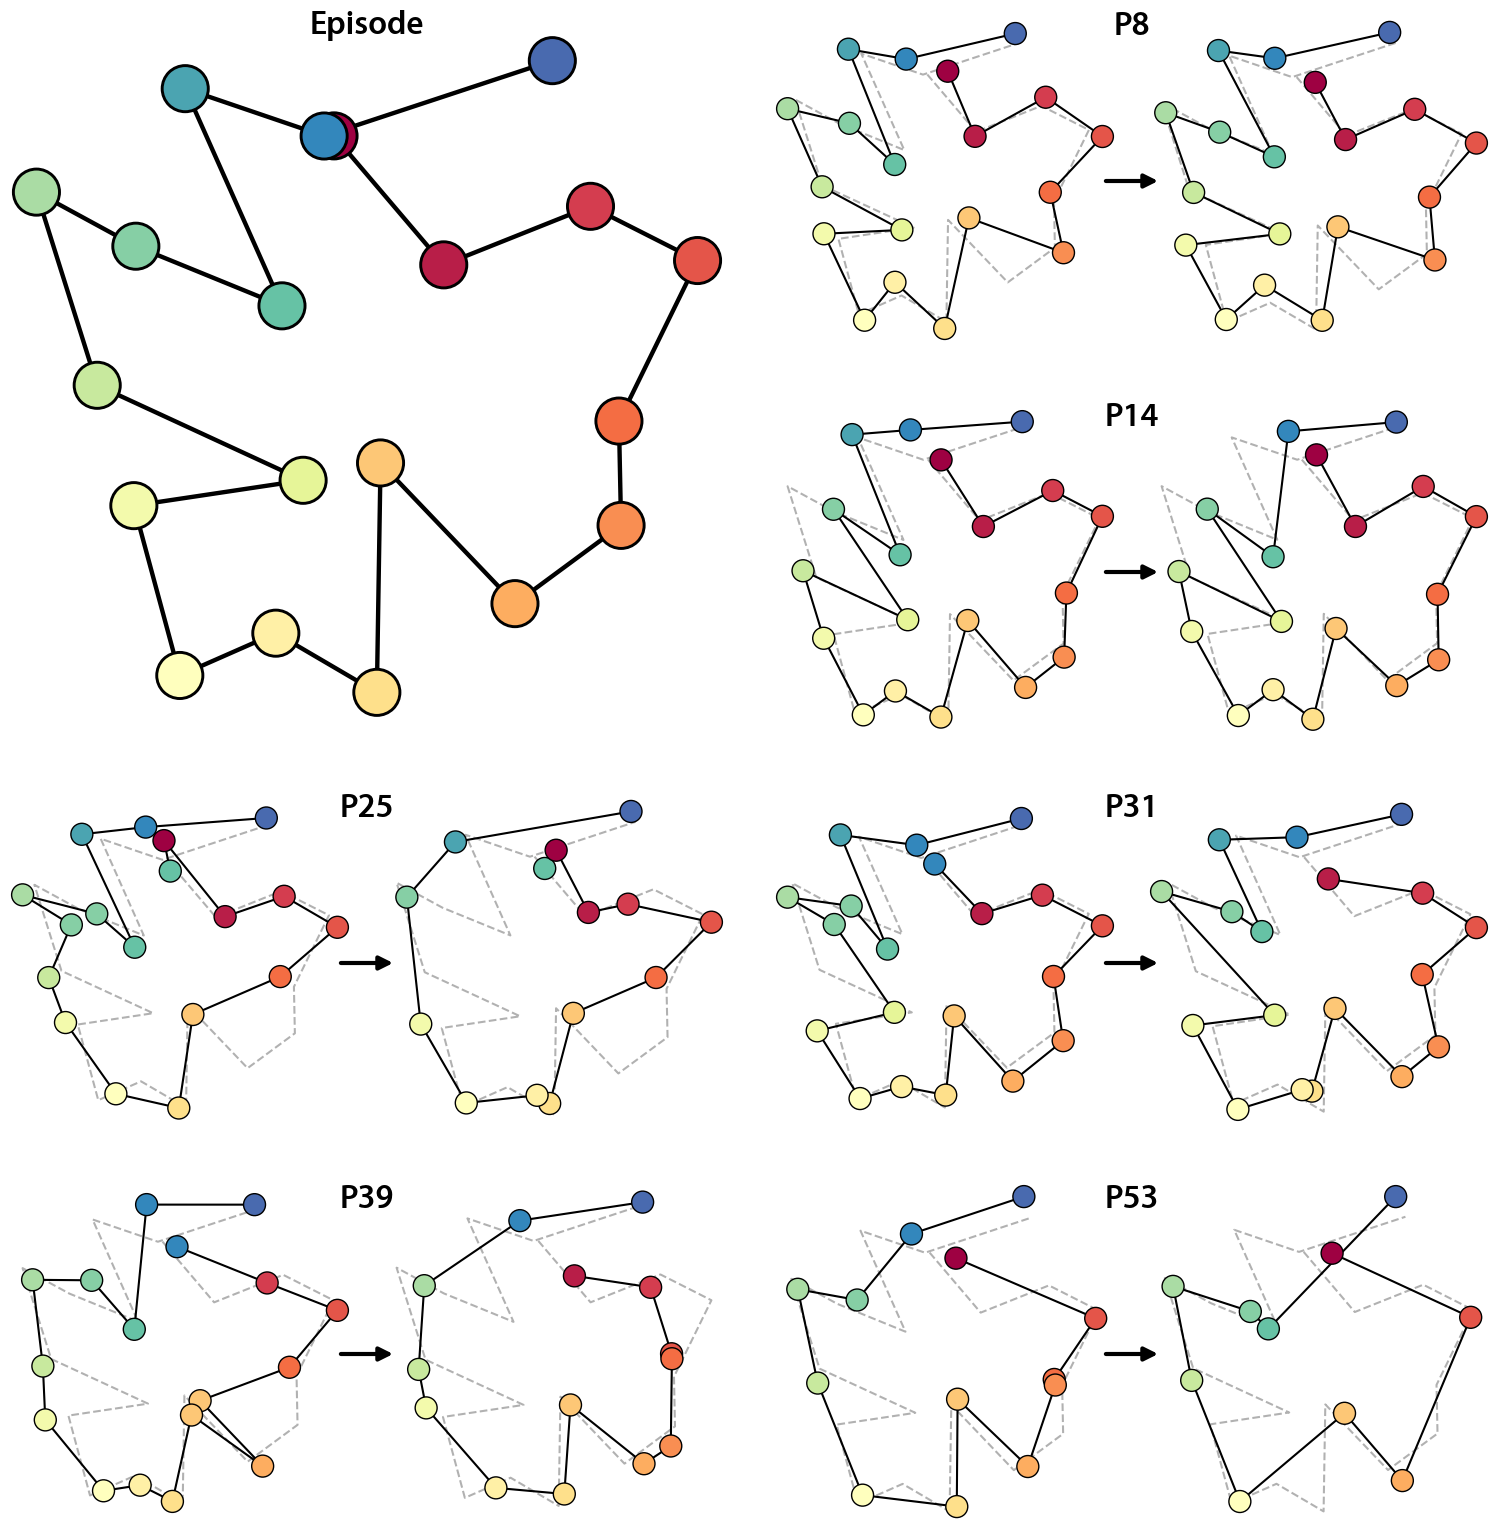

In [171]:
# IMPORTS
import pickle

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch


# FUNCTIONS/CLASSES
def add_arrows(axes, x, y, aspace=1.5, head_width=None, arrow_length=None,
               **kwargs):
    # aspace sets the spacing between arrows; head_width and arrow_length set
    # the arrow size independently (defaulting to the original aspace-derived
    # values so behavior is unchanged unless they're passed explicitly).
    if head_width is None:
        head_width = aspace / 3
    if arrow_length is None:
        arrow_length = aspace / 10

    # distance spanned between pairs of points
    r = [0]
    for i in range(1, len(x)):
        dx = x[i] - x[i - 1]
        dy = y[i] - y[i - 1]
        r.append(np.sqrt(dx * dx + dy * dy))

    r = np.array(r)
    # cumulative sum of r, used to save time
    rtot = []
    for i in range(len(r)):
        rtot.append(r[0:i].sum())
    rtot.append(r.sum())
    # will hold tuple(x, y, theta) for each arrow
    arrow_data = []
    # current point on walk along data
    arrow_pos = 0
    rcount = 1
    while arrow_pos < r.sum():
        x1, x2 = x[rcount - 1], x[rcount]
        y1, y2 = y[rcount - 1], y[rcount]
        da = arrow_pos - rtot[rcount]
        theta = np.arctan2((x2 - x1), (y2 - y1))
        ax = np.sin(theta) * da + x1
        ay = np.cos(theta) * da + y1
        arrow_data.append((ax, ay, theta))
        arrow_pos += aspace
        while arrow_pos > rtot[rcount + 1]:
            rcount += 1
            if arrow_pos > rtot[-1]:
                break

    for ax, ay, theta in arrow_data:
        axes.arrow(ax,
                   ay,
                   np.sin(theta) * arrow_length,
                   np.cos(theta) * arrow_length,
                   head_width=head_width,
                   **kwargs)


# LOAD DATA
with open('trajs_2d_data.pkl', 'rb') as f:
    trajs_2d = pickle.load(f)

# CONSTANTS
# shared
EVENT_CMAP = plt.cm.Spectral
CONNECTION_LINE_COLOR = 'k'
AXES_TITLE_FONTSIZE = 24

# When True, each recall panel is framed to fit its own recall path together
# with the episode path drawn beneath it (the underlay), so the content fills the
# panel and whitespace is minimized without clipping the underlay. When False,
# recall panels use the shared fixed limits (the current behavior). Either way
# equal aspect is kept (no distortion) and the episode is framed to its own extent.
FIT_TO_PATH = True
ARROW_COLOR = 'k'
ARROW_ALPHA = 1
# Arrow spacing and size are independent knobs, both in DATA units. Because
# every panel shares the same data bounds, one set of values keeps arrows
# proportional to each panel's path.
ARROW_ASPACE = 3         # spacing between arrows
ARROW_HEAD_WIDTH = 1     # arrowhead width
ARROW_LENGTH = 0.42      # arrow shaft length (head length follows head width)

# arrow drawn in the gap between each participant's immediate and delayed panels
# (pointing right: immediate -> delayed)
PAIR_ARROW_COLOR = 'k'
PAIR_ARROW_LINEWIDTH = 3
PAIR_ARROW_HEAD_SCALE = 20      # arrowhead size (points)
PAIR_ARROW_LENGTH_FRAC = 1.7   # shaft length as a fraction of the pair gap

# very light grey rounded background behind each immediate+delayed pair, to
# group the two paths visually. Drawn behind everything and sized to the pair's
# own bounding box, so it doesn't change the layout or add whitespace.
PAIR_BG_COLOR = 'k'         # very light grey
PAIR_BG_ROUNDING = 0.012       # corner radius (figure fraction); slightly rounded
PAIR_BG_PAD = 0.0              # extra padding around the pair (figure fraction)
PAIR_BG_ZORDER = -10           # behind the (transparent) axes
EPISODE_BOX = True             # draw the same style box around the episode path

# episode
# The episode path uses the SAME visual style as the recalls, just scaled up to
# match its larger axis (so the recalls read as smaller versions of it). Its dot
# size and linewidths are therefore derived from the recall values and the
# episode/recall axis-size ratio (see panel_style / EPISODE_SCALE below) rather
# than set independently here.
EPISODE_EVENT_BORDER_COLOR = 'k'

# recalls  (these double as the base style that the episode is scaled up from)
RECALL_EVENT_MARKERSIZE = 250
RECALL_EVENT_BORDER_LINEWIDTH = 1
RECALL_EVENT_BORDER_COLOR = 'k'
RECALL_CONNECTION_LINEWIDTH = 1.5
RECALL_EPISODE_UNDERLAY_COLOR = 'k'
RECALL_EPISODE_UNDERLAY_ALPHA = 0.3
RECALL_EPISODE_UNDERLAY_LINEWIDTH = 1.5
RECALL_EPISODE_UNDERLAY_LINESTYLE = '--'

EXAMPLE_PARTICIPANTS = [
    'P8',
    'P14',
    'P25',
    'P31',
    'P39',
    'P53'
]

# CREATE FIGURE

# number of episode events; event colors are the Spectral colormap indexed by
# (event's matched episode-event index / N_EPISODE_EVENTS), so a recall event
# gets the same color as the episode event it's matched to. An episode event is
# its own match, so the episode uses arange(N_EPISODE_EVENTS).
N_EPISODE_EVENTS = trajs_2d['episode_path'].shape[0]


def match_colors(match_indices):
    """Color each event by its matched episode event's color."""
    return EVENT_CMAP(match_indices / N_EPISODE_EVENTS)


def draw_underlay(axes, path):
    """Faint episode path (line only) drawn beneath a recall path."""
    axes.plot(path[:, 0], path[:, 1],
              color=RECALL_EPISODE_UNDERLAY_COLOR,
              alpha=RECALL_EPISODE_UNDERLAY_ALPHA,
              linewidth=RECALL_EPISODE_UNDERLAY_LINEWIDTH,
              linestyle=RECALL_EPISODE_UNDERLAY_LINESTYLE,
              zorder=0)


def draw_path(axes, path, colors, connection_linewidth,
              marker_size, border_linewidth, border_color):
    """Draw one trajectory: connecting line, direction arrows, event dots."""
    x, y = path[:, 0], path[:, 1]

    # connecting line (behind the event dots)
    axes.plot(x, y,
              color=CONNECTION_LINE_COLOR,
              linewidth=connection_linewidth,
              zorder=1)

    # direction arrows along the connecting line (above line, below dots).
    # Disabled for now — uncomment to bring the arrows back.
#     add_arrows(axes, x, y,
#                aspace=ARROW_ASPACE,
#                head_width=ARROW_HEAD_WIDTH,
#                arrow_length=ARROW_LENGTH,
#                color=ARROW_COLOR,
#                alpha=ARROW_ALPHA,
#                zorder=2,
#                length_includes_head=False)

    # event dots on top
    axes.scatter(x, y,
                 c=colors,
                 s=marker_size,
                 edgecolors=border_color,
                 linewidths=border_linewidth,
                 zorder=3)


def style_axis(axes, xlim=None, ylim=None):
    """Equal aspect, no spines, no ticks, no background. Uses the shared bounds
    by default, or the given (xlim, ylim) for a panel framed to its own path."""
    axes.set_xlim(*(xlim if xlim is not None else XLIM))
    axes.set_ylim(*(ylim if ylim is not None else YLIM))
    axes.set_aspect('equal')
    axes.set_facecolor('none')
    axes.set_xticks([])
    axes.set_yticks([])
    for spine in axes.spines.values():
        spine.set_visible(False)


def framed_limits(path, box_aspect, margin=None):
    """(xlim, ylim) centered on `path`, covering it with `margin` padding and
    matching a panel of the given box_aspect (= width / height). Combined with
    equal aspect, this lets the axis fill its (possibly non-square) cell with no
    distortion, while framing tightly to the path so it fills the panel."""
    if margin is None:
        margin = DATA_BOUNDS_MARGIN
    (xmin, ymin), (xmax, ymax) = path.min(0), path.max(0)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    xr, yr = (xmax - xmin) * (1 + margin), (ymax - ymin) * (1 + margin)
    # grow whichever dimension is too small so that xr / yr == box_aspect
    if xr / yr > box_aspect:
        yr = xr / box_aspect
    else:
        xr = yr * box_aspect
    return (cx - xr / 2, cx + xr / 2), (cy - yr / 2, cy + yr / 2)


def panel_style(scale):
    """Point-based sizes for a panel whose axis is `scale`x the linear size of a
    recall panel. Marker *area* scales with scale**2; linewidths (linear) scale
    with scale. (Arrows are drawn in data units, so they scale automatically and
    aren't included here.)"""
    return dict(
        marker_size=RECALL_EVENT_MARKERSIZE * scale ** 2,
        border_linewidth=RECALL_EVENT_BORDER_LINEWIDTH * scale,
        connection_linewidth=RECALL_CONNECTION_LINEWIDTH * scale,
    )


# index participant data by subject ID for easy lookup
participants_by_id = {p[0]: p for p in trajs_2d['participant_data']}

# shared data bounds: one square window covering every displayed path, so all
# panels use identical data-unit limits (rather than each centering on its own
# path). Combined with equal aspect this keeps geometry undistorted.
DATA_BOUNDS_MARGIN = 0.08  # fraction of the span added as padding


def compute_shared_bounds():
    paths = [trajs_2d['episode_path']]
    for sid in EXAMPLE_PARTICIPANTS:
        _, imm_path, _, del_path, _ = participants_by_id[sid]
        paths.extend([imm_path, del_path])
    stacked = np.vstack(paths)
    (xmin, ymin), (xmax, ymax) = stacked.min(0), stacked.max(0)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    half = max(xmax - xmin, ymax - ymin) / 2 * (1 + DATA_BOUNDS_MARGIN)
    return (cx - half, cx + half), (cy - half, cy + half)


XLIM, YLIM = compute_shared_bounds()

# grid placement for each example participant: (row, immediate_col, delayed_col)
# rows and columns are content indices 0-3 (see COL_X / ROW_Y); each
# participant's immediate+delayed pair falls within one half (cols 0-1 or 2-3).
PARTICIPANT_PLACEMENTS = [
    (0, 2, 3),
    (1, 2, 3),
    (2, 0, 1),
    (2, 2, 3),
    (3, 0, 1),
    (3, 2, 3),
]

# --- Layout ------------------------------------------------------------------
# Panels are placed at explicit positions (via add_axes) rather than a single
# gridspec, so gaps live strictly BETWEEN panels -- the episode is a clean square
# and never absorbs the inter-panel spacing. Everything is in units of one recall
# panel (a 1x1 square); the figure is sized from those units so panels stay
# physically square and the layout auto-rescales when any gap changes.
PANEL_IN = 3.4      # side length of one recall panel (inches)
PAIR_GAP = 0.1     # horizontal gap within an immediate+delayed pair
GROUP_GAP = 0.15     # horizontal gap between the two pairs (and episode <-> pairs)
ROW_GAP = 0.15      # vertical gap above each row (also holds the row's title)

# episode occupies the top-left 2x2 block of the recall grid: its width matches
# the C0-C1 pair beneath it (which also leaves a GROUP_GAP to the P8/P14 pair),
# and its height matches the two recall rows beside it (R0-R1). It is therefore
# not square when PAIR_GAP != ROW_GAP, but the path is still drawn undistorted
# (equal aspect) because framed_limits fills the box at its own aspect ratio.
EPISODE_W = 2 + PAIR_GAP   # width  = C0-C1 pair span
EPISODE_H = 2 + ROW_GAP    # height = R0-R1 row span
EPISODE_SCALE = EPISODE_W  # episode axis width relative to a recall panel

# content-column left edges and content-row top edges (top edge measured
# downward from the top of the figure), in panel units
COL_X = [0.0,
         1 + PAIR_GAP,
         2 + PAIR_GAP + GROUP_GAP,
         3 + 2 * PAIR_GAP + GROUP_GAP]
ROW_Y = [(r + 1) * ROW_GAP + r for r in range(4)]

TOTAL_W = 4 + 2 * PAIR_GAP + GROUP_GAP
TOTAL_H = 4 + 4 * ROW_GAP
FIG_W = TOTAL_W * PANEL_IN
FIG_H = TOTAL_H * PANEL_IN


def cell(x_left, y_top, w, h):
    """Panel-unit rectangle (x from the left, y measured downward from the top)
    -> Matplotlib [left, bottom, width, height] figure-fraction rectangle."""
    return [x_left / TOTAL_W,
            (TOTAL_H - y_top - h) / TOTAL_H,
            w / TOTAL_W,
            h / TOTAL_H]


fig = plt.figure(figsize=(FIG_W, FIG_H))
fig.patch.set_alpha(0)
episode_path = trajs_2d['episode_path']

# --- Create all axes (episode + each participant's immediate/delayed) ---
ax_episode = fig.add_axes(cell(COL_X[0], ROW_Y[0], EPISODE_W, EPISODE_H))
participant_axes = []  # (sid, ax_immediate, ax_delayed)
for sid, (row, col_imm, col_del) in zip(EXAMPLE_PARTICIPANTS, PARTICIPANT_PLACEMENTS):
    y = ROW_Y[row]
    ax_imm = fig.add_axes(cell(COL_X[col_imm], y, 1, 1))
    ax_del = fig.add_axes(cell(COL_X[col_del], y, 1, 1))
    participant_axes.append((sid, ax_imm, ax_del))

# --- Episode (drawn at its scaled-up style) ---
# framed to its own extent (not the shared window) so it fills its square panel;
# the recall panels keep the shared bounds, so their comparisons + the grey
# episode underlay are unaffected.
ep_xlim, ep_ylim = framed_limits(episode_path, EPISODE_W / EPISODE_H)
draw_path(ax_episode, episode_path,
          colors=match_colors(np.arange(N_EPISODE_EVENTS)),
          border_color=EPISODE_EVENT_BORDER_COLOR,
          **panel_style(EPISODE_SCALE))
style_axis(ax_episode, xlim=ep_xlim, ylim=ep_ylim)

# --- Example participants' immediate + delayed recalls (base style) ---
for sid, ax_imm, ax_del in participant_axes:
    _, imm_path, imm_match, del_path, del_match = participants_by_id[sid]
    for axes, path, match in ((ax_imm, imm_path, imm_match),
                              (ax_del, del_path, del_match)):
        draw_underlay(axes, episode_path)
        draw_path(axes, path,
                  colors=match_colors(match),
                  border_color=RECALL_EVENT_BORDER_COLOR,
                  **panel_style(1.0))
        if FIT_TO_PATH:
            # include the episode path so the underlaid episode isn't clipped
            fit_pts = np.vstack([path, episode_path])
            xlim, ylim = framed_limits(fit_pts, 1.0)  # recall panels are square
            style_axis(axes, xlim=xlim, ylim=ylim)
        else:
            style_axis(axes)

# --- Titles ---
# episode title
ax_episode.set_title('Episode', fontsize=AXES_TITLE_FONTSIZE, va='top', y=1-0.01, fontweight='semibold')

# participant titles, centered between each participant's two axes
fig.canvas.draw()  # finalize axis positions before reading them

# # --- Light grey rounded background behind each pair ---
# for sid, ax_imm, ax_del in participant_axes:
#     box_imm = ax_imm.get_position()
#     box_del = ax_del.get_position()
#     x0, x1 = box_imm.x0 - PAIR_BG_PAD, box_del.x1 + PAIR_BG_PAD
#     y0, y1 = box_imm.y0 - PAIR_BG_PAD, box_imm.y1 + PAIR_BG_PAD
#     fig.add_artist(FancyBboxPatch(
#         (x0, y0), x1 - x0, y1 - y0,
#         boxstyle=f'round,pad=0,rounding_size={PAIR_BG_ROUNDING}',
#         transform=fig.transFigure, facecolor=PAIR_BG_COLOR, alpha=0.03, edgecolor='none',
#         zorder=PAIR_BG_ZORDER, clip_on=False))

# # --- Optional box around the episode path (same style as the pair backgrounds) ---
# if EPISODE_BOX:
#     box = ax_episode.get_position()
#     fig.add_artist(FancyBboxPatch(
#         (box.x0 - PAIR_BG_PAD, box.y0 - PAIR_BG_PAD),
#         box.width + 2 * PAIR_BG_PAD, box.height + 2 * PAIR_BG_PAD,
#         boxstyle=f'round,pad=0,rounding_size={PAIR_BG_ROUNDING}',
#         transform=fig.transFigure, facecolor=PAIR_BG_COLOR, alpha=0.03, edgecolor='none',
#         zorder=PAIR_BG_ZORDER, clip_on=False))

for sid, ax_imm, ax_del in participant_axes:
    box_imm = ax_imm.get_position()
    box_del = ax_del.get_position()
    center_x = (box_imm.x0 + box_del.x1) / 2
    top_y = max(box_imm.y1, box_del.y1)
    fig.text(center_x, top_y, sid,
             ha='center', va='top',
             fontsize=AXES_TITLE_FONTSIZE, fontweight='semibold')

# --- Arrow from each participant's immediate to delayed path ---
# drawn in the gap between the pair, pointing right, vertically centered
for sid, ax_imm, ax_del in participant_axes:
    box_imm = ax_imm.get_position()
    box_del = ax_del.get_position()
    y = (box_imm.y0 + box_imm.y1) / 2
    gap_center = (box_imm.x1 + box_del.x0) / 2
    half_len = (box_del.x0 - box_imm.x1) * PAIR_ARROW_LENGTH_FRAC / 2
    fig.add_artist(FancyArrowPatch(
        (gap_center - half_len, y), (gap_center + half_len, y),
        transform=fig.transFigure, arrowstyle='-|>',
        mutation_scale=PAIR_ARROW_HEAD_SCALE, linewidth=PAIR_ARROW_LINEWIDTH,
        color=PAIR_ARROW_COLOR, clip_on=False))

# plt.savefig(FIG_DIR / '2d-trajectories.pdf', bbox_inches='tight')

plt.show()